In [7]:
%pylab inline
import pandas as pd
from qqman import qqman

Populating the interactive namespace from numpy and matplotlib


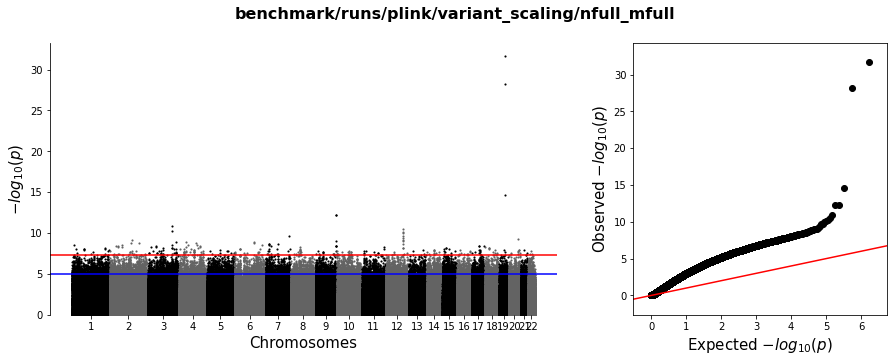

In [13]:
data = pd.read_csv("benchmark/runs/plink/variant_scaling/nfull_mfull/result.assoc.linear", delim_whitespace=True)
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
fig.set_size_inches((15, 5))
fig.suptitle("benchmark/runs/plink/variant_scaling/nfull_mfull", fontsize=16, fontweight='bold')
qqman.manhattan(data, ax=ax0)
qqman.qqplot(data, ax=ax1)

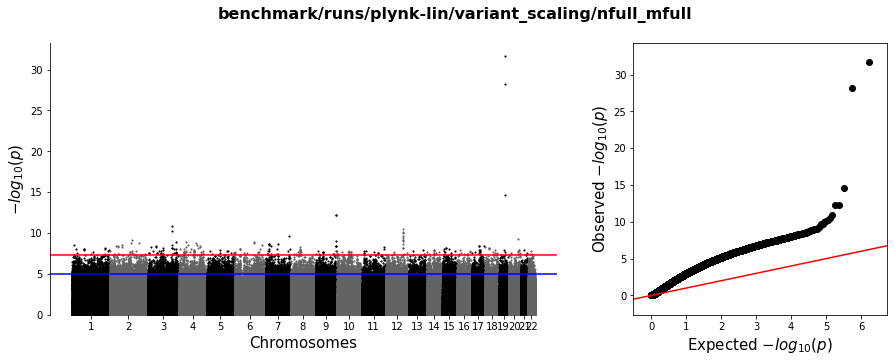

In [15]:
data = pd.read_csv("benchmark/runs/plynk-lin/variant_scaling/nfull_mfull/result.assoc.linear", delim_whitespace=True)
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
fig.set_size_inches((15, 5))
fig.suptitle("benchmark/runs/plynk-lin/variant_scaling/nfull_mfull", fontsize=16, fontweight='bold')
qqman.manhattan(data, ax=ax0)
qqman.qqplot(data, ax=ax1)

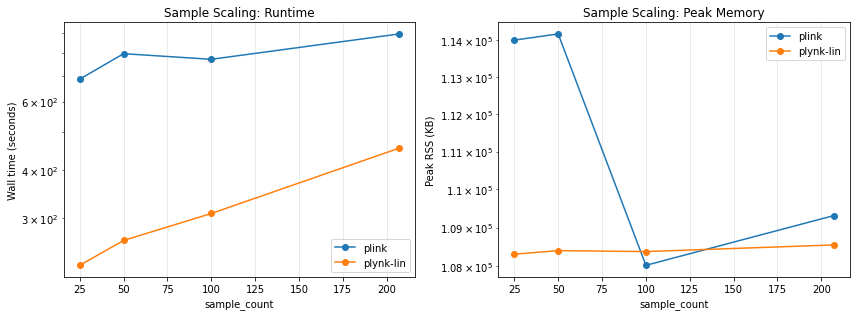

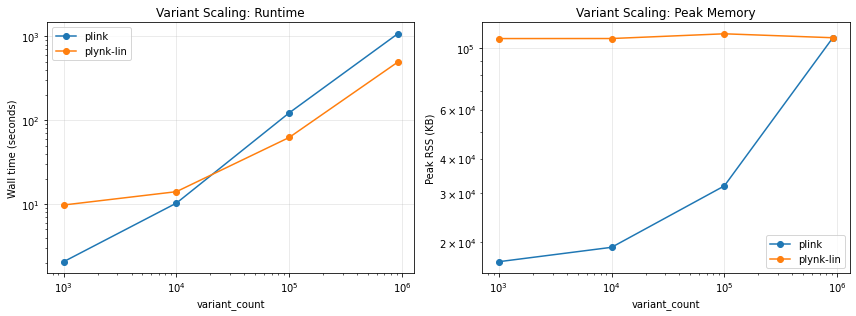

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1) Read in CSV ===
plynk_csv = "benchmark/results_prj.csv"
plink_csv = "benchmark/results_plink.csv"


df_plynk = pd.read_csv(plynk_csv)
df_plink = pd.read_csv(plink_csv)

df = pd.concat([df_plynk, df_plink], ignore_index=True)

df["tool"] = df["tool"].replace({
    "plynk-lin": "plynk-lin",
    "plink": "plink"
})

# ==== 2) split by dataset family ====
df_sample = df[df["dataset_family"] == "sample_scaling"].copy()
df_variant = df[df["dataset_family"] == "variant_scaling"].copy()

df_sample = df_sample.sort_values(["tool", "sample_count"])
df_variant = df_variant.sort_values(["tool", "variant_count"])

# ==== 3) helper plotting function ====
def plot_scaling(df_sub, x_col, family_name, variant_scaling=False):
    tools = df_sub["tool"].unique()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # --- runtime plot ---
    for tool in tools:
        part = df_sub[df_sub["tool"] == tool].sort_values(x_col)
        axes[0].plot(part[x_col], part["wall_seconds"], marker="o", label=tool)

    axes[0].set_title(f"{family_name}: Runtime")
    axes[0].set_xlabel(x_col)
    axes[0].set_ylabel("Wall time (seconds)")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # --- memory plot ---
    for tool in tools:
        part = df_sub[df_sub["tool"] == tool].sort_values(x_col)
        axes[1].plot(part[x_col], part["peak_rss_kb"], marker="o", label=tool)

    axes[1].set_title(f"{family_name}: Peak Memory")
    axes[1].set_xlabel(x_col)
    axes[1].set_ylabel("Peak RSS (KB)")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    if variant_scaling:
        axes[0].set_xscale("log")
        axes[0].set_yscale("log")
        axes[1].set_xscale("log")
        axes[1].set_yscale("log")
    else:
        axes[0].set_yscale("log")
        axes[1].set_yscale("log")
        

    fig.tight_layout()
    return fig, axes

# ==== 4) draw the two 1x2 figures ====
plot_scaling(df_sample, "sample_count", "Sample Scaling")
plot_scaling(df_variant, "variant_count", "Variant Scaling", variant_scaling=True)

plt.show()